# Value-gradient propagation — Phase 1

**The question.** Can the critic's gradient `∂V/∂p` (how the value changes if you nudge a leg's
presence) serve as the training signal for a future morphology *generator* — emit a body, push it
uphill on `V`? Presence is a continuous probability `p∈[0,1]` fed to the critic (both length slots);
the body is Bernoulli-sampled from `p`, so `V(p)≈E[return]` and `∂V/∂p` is a smooth in-distribution
signal whose **sign** should track the desired leg state (**+** = should-be-on, **−** = should-be-off,
regardless of the leg's current state — it's "which way should this move", not an importance score).

**The short answer (this notebook).** Yes on *sign*: the gradient is positive almost everywhere (no
myopia), it generalizes onto held-out bodies, and it survives being composed through a generator net
— the exact thing that broke the earlier binary version. The soft spot is *magnitude*: it's weakest
right where a generator would most want it (bootstrapping a near-off leg). Loads every seed under
`data/value_grad_prop/*/grad.npz`. Full write-up: `docs/value_gradient_propagation.md`.

In [10]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
runs = sorted((ROOT / 'data' / 'value_grad_prop').glob('*/grad.npz'))
D = {p.parent.name: np.load(p, allow_pickle=True) for p in runs}
print('seeds:', list(D))
EDGES = np.linspace(0.0, 1.0, 11)            # 10 p-bins for the dV/dp-vs-p headline
CEN = 0.5 * (EDGES[:-1] + EDGES[1:])

def per_leg(d):
    """Flatten (env,leg) -> p, g_mean, g0, and the env's sampled leg count broadcast per leg."""
    p, gm, g0, lc = d['p'], d['g_mean'], d['g0'], d['leg_count']
    lc8 = np.repeat(lc[:, None], 8, 1)
    return dict(p=p.ravel(), gm=gm.ravel(), g0=g0.ravel(), lc=lc8.ravel())
P = {s: per_leg(d) for s, d in D.items()}

def binned(p, g):
    """Mean of g within each p-bin (nan if empty)."""
    idx = np.clip(np.digitize(p, EDGES) - 1, 0, len(EDGES) - 2)
    return np.array([g[idx == b].mean() if (idx == b).any() else np.nan for b in range(len(CEN))])

seeds: ['s42', 's43', 's44']


## Premise sanity — reward vs sampled on-leg count ("more legs better")

**Hypothesis.** The whole Step-1 logic rests on "more legs → more reward." If that holds, raising any
leg's `p` should help, so a useful gradient ought to point *up* (positive) everywhere. First confirm
the premise itself.

**How it works.** One line per seed: mean episode reward vs the **sampled** Bernoulli body's on-leg
count. (Count 5 is held out of training — the guard rejects 5-leg builds — so it's absent here.)

**What we found.** Clean, strong monotonic climb across all three seeds — roughly a few hundred reward
at 2 legs up to ~4600–5200 at 8 legs. The premise holds, no surprises; on to the actual gradient.

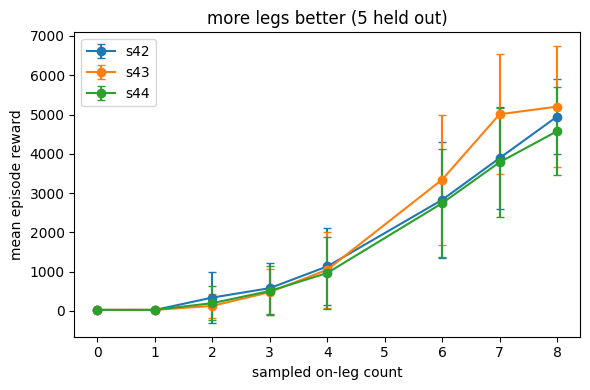

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = sorted(set(np.concatenate([d['leg_count'] for d in D.values()]).tolist()))
for s, d in D.items():
    lc, rew = d['leg_count'], d['ep_reward']
    m  = [rew[lc == k].mean() if (lc == k).any() else np.nan for k in counts]
    sd = [rew[lc == k].std()  if (lc == k).any() else np.nan for k in counts]
    ax.errorbar(counts, m, yerr=sd, marker='o', capsize=3, label=s)
ax.set_xlabel('sampled on-leg count'); ax.set_ylabel('mean episode reward')
ax.legend(); ax.set_title('more legs better (5 held out)')
plt.tight_layout(); plt.show()

## Myopia headline — `∂V/∂p` binned by `p`

**Hypothesis.** Two parts. (1) *The real worry — myopia:* is `∂V/∂p` **positive at low `p`** (so ascent
can grow a useful-but-absent leg), or negative (a nascent stub looks locally harmful and ascent gets
stuck off)? (2) *A guess about shape:* we figured the add-signal would be **largest at low `p`** (most
to gain) and taper toward `p=1` (diminishing returns).

**How it works.** Pool every (env, leg) pair across the training population, bin by `p`, and plot mean
`∂V/∂p` vs `p` (one faint line per seed, bold = pooled).

**What we found.** No myopia — `∂V/∂p` is **positive everywhere**, with ≥~85% of legs positive even in
the lowest `p` bin, so ascent *can* grow an absent leg. **But the shape guess was backwards:** the
gradient is *weakest* at low `p` (~+2.7) and grows to ~+7 across the mid/high range, barely drooping at
`p=1`. So the signal is smallest exactly where a generator would need it most — bootstrapping a leg
from near-off. Ascent will work, but it starts slow.

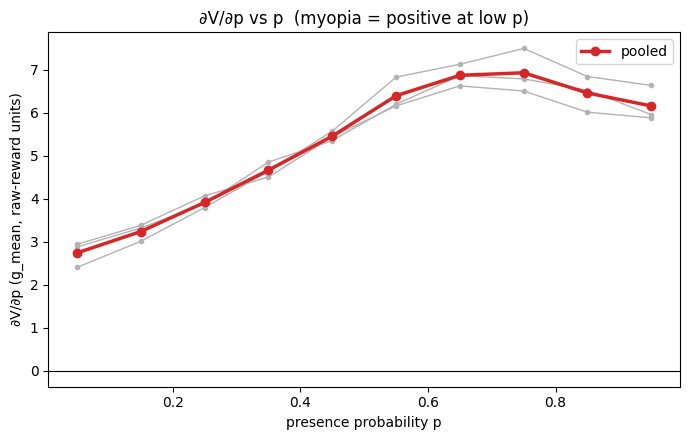

pooled frac>0 at low p (p<0.2): 0.881


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for s, p in P.items():
    ax.plot(CEN, binned(p['p'], p['gm']), color='0.7', lw=1, marker='.', zorder=1)
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ax.plot(CEN, binned(pp, gg), color='C3', lw=2.5, marker='o', label='pooled', zorder=3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean, raw-reward units)')
ax.set_title('∂V/∂p vs p  (myopia = positive at low p)'); ax.legend()
plt.tight_layout(); plt.show()
print('pooled frac>0 at low p (p<0.2):', (gg[pp < 0.2] > 0).mean().round(3))

## Marginal value — `∂V/∂p` vs `p`, split by body fullness

**Hypothesis.** Diminishing returns *across bodies*: a sparse body (few legs) should value an extra leg
**more** than a full one, so splitting the curve into **sparse** (≤3 on) vs **full** (≥6 on) should put
the sparse curve clearly **above** the full one.

**How it works.** Same binned `∂V/∂p`-vs-`p` curve (pooled over seeds), but each (env, leg) pair sorted
by its body's sampled on-leg count into the two groups.

**What we found.** The ordering is actually **reversed for most of the range** — full bodies sit *above*
sparse ones until they **cross near `p=1`**. The real diminishing-returns signature isn't a level shift;
it's that the **full curve droops as `p`→1** (its legs becoming redundant) while the sparse curve keeps
climbing and overtakes it. So "fewer legs ⇒ each leg more valuable" only shows up at high `p`, not as
the clean sparse-above-full separation we expected.

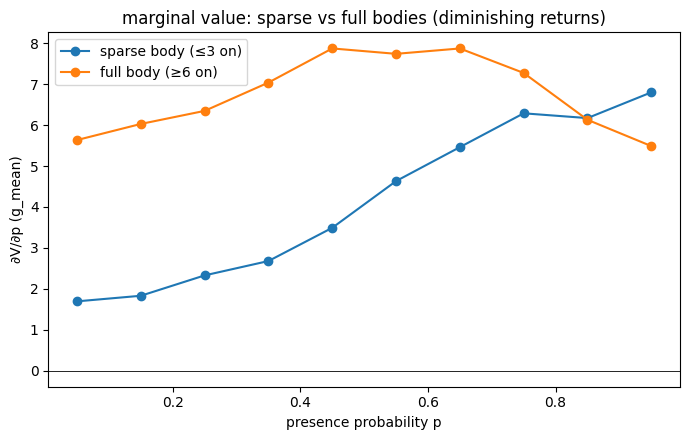

In [13]:
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ll = np.concatenate([p['lc'] for p in P.values()])
fig, ax = plt.subplots(figsize=(7, 4.5))
for mask, c, lb in [(ll <= 3, 'C0', 'sparse body (≤3 on)'), (ll >= 6, 'C1', 'full body (≥6 on)')]:
    ax.plot(CEN, binned(pp[mask], gg[mask]), marker='o', color=c, label=lb)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean)')
ax.set_title('marginal value: sparse vs full bodies (diminishing returns)'); ax.legend()
plt.tight_layout(); plt.show()

## Why is ∂V/∂p small at low p? — quorum / S-curve test

**Hypothesis.** Low-p legs look low-value for two linked reasons. (1) *Statistical:* a leg's own `p` is
correlated with its body's overall fullness (off-legs of sparse centers draw low `p`), so binning by `p`
partly just re-reads a "value vs fullness" curve. (2) *Substantive:* locomotion needs a **quorum** of
legs — one barely-present leg on a barely-functional body genuinely adds little (you're on the flat
bottom of an S-shaped return-vs-legcount curve), whereas a leg joining an already-walking body pays off.
If (2) is real, the gradient should keep rising with `p` *even within a fixed leg-count*; if only (1) is
at work, each fixed-count curve goes flat.

**How it works.** *Left:* `∂V/∂p` vs `p` split by the body's on-leg count — does the within-count curve
stay flat (slope was just the fullness confound) or keep rising (real near-threshold convexity)?
*Right:* mean `∂V/∂p` vs body leg-count at a mid-`p` band (`p∈[0.4,0.6]`, which strips out the
`p`↔fullness correlation) — the marginal-value-vs-fullness "S-curve" read straight off the gradients.

**What we found.** Both effects are real. The `p`↔leg-count correlation is **+0.30** (low-`p` legs do
live in sparser bodies), but within *every* fixed leg-count the gradient **still climbs with `p`** —
steeply at low counts (2 legs: +1.1→+7.4) and flattening then drooping at high counts (8 legs:
+6.8→+4.0, i.e. redundancy). And the right panel is a clear **hump**: marginal value rises from ~+1
(1 leg) to a peak ~+7 (6 legs), then declines (7–8 legs). So a near-off leg is low-value because it
sits at the **bottom of the S-curve** — you need a quorum before any single leg pays off. That's exactly
the regime a generator must climb out of, and why ascent bootstraps slowly.

In [ ]:
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ll = np.concatenate([p['lc'] for p in P.values()])
counts = sorted(c for c in set(ll.tolist()) if (ll == c).sum() > 200)   # body leg-counts with support

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ∂V/∂p vs p WITHIN fixed body leg-count -> disambiguate fullness-confound vs real p-convexity.
cmap = plt.cm.viridis(np.linspace(0, 1, len(counts)))
for c, col in zip(counts, cmap):
    m = ll == c
    axL.plot(CEN, binned(pp[m], gg[m]), marker='o', ms=4, color=col, label=f'{int(c)} legs')
axL.axhline(0, color='k', lw=0.6)
axL.set_xlabel('presence probability p'); axL.set_ylabel('∂V/∂p (g_mean)')
axL.set_title('∂V/∂p vs p, within fixed body leg-count')
axL.legend(title='body on-legs', fontsize=8, ncol=2)

# Right: marginal value vs body leg-count at a mid-p band (strips the p↔fullness confound) -> the S-curve.
mid = (pp >= 0.4) & (pp <= 0.6)
xs = np.array(counts, float)
ys = np.array([gg[mid & (ll == c)].mean() for c in counts])
es = np.array([gg[mid & (ll == c)].std() / np.sqrt((mid & (ll == c)).sum()) for c in counts])
axR.errorbar(xs, ys, yerr=es, marker='o', capsize=3, color='C3')
axR.axhline(0, color='k', lw=0.6)
axR.set_xlabel('body on-leg count'); axR.set_ylabel('∂V/∂p at p∈[0.4,0.6]')
axR.set_title('marginal value vs body fullness (the S-curve)')

r = np.corrcoef(pp, ll)[0, 1]
fig.suptitle(f'why ∂V/∂p is small at low p   |   corr(leg p, body leg-count) = {r:+.2f}', y=1.03)
plt.tight_layout(); plt.show()

## `g0` (t=0 reset) vs `g_mean` (rollout) — static prior vs rolled-out signal

**Hypothesis.** The gradient at the canonical reset pose (`g0`) should roughly match the one averaged
over a real rollout (`ḡ`) — points hugging the identity line — which would mean the signal is the value
net's stable *prior*, not an artifact of particular dynamic states.

**How it works.** Each point is one (env, leg): `g0` (x) vs `ḡ` (y), colored by the leg's `p`; dashed
line = identity.

**What we found.** They **don't** hug the line. `g0` is wildly inflated — about **4× the spread** of `ḡ`
(mean ~+21 vs ~+5), correlates only ~0.32, and agrees on sign just 87% of the time (it even dips
negative). The static reset-pose prior is a blown-up, unreliable proxy → **trust the rollout-averaged
`ḡ`**, which is what a generator would actually see.

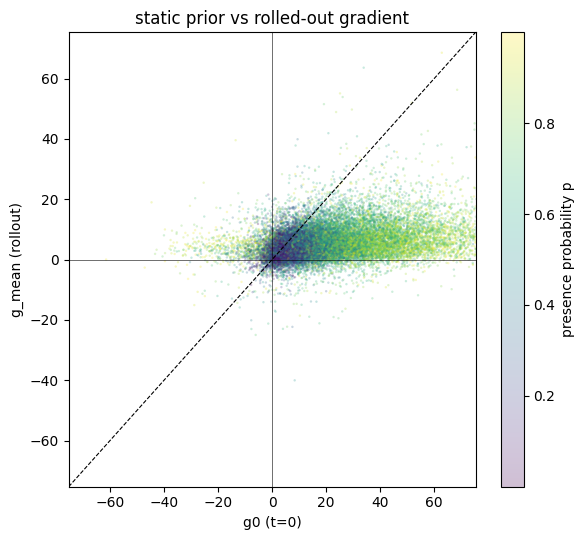

In [14]:
g0 = np.concatenate([p['g0'] for p in P.values()]); gmn = np.concatenate([p['gm'] for p in P.values()])
pv = np.concatenate([p['p'] for p in P.values()])
fig, ax = plt.subplots(figsize=(6, 5.5))
sc = ax.scatter(g0, gmn, s=3, alpha=0.25, c=pv, cmap='viridis', edgecolors='none', rasterized=True)
lim = np.percentile(np.abs(np.r_[g0, gmn]), 99)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_xlabel('g0 (t=0)'); ax.set_ylabel('g_mean (rollout)')
fig.colorbar(sc, label='presence probability p'); ax.set_title('static prior vs rolled-out gradient')
plt.tight_layout(); plt.show()

## Step 2 — curated held-out morphologies vs trained twins

**Hypothesis.** Per-leg intuition on three hand-picked **held-out** bodies: *redundancy* {2,5,6,7} → the
lone leg carries balance (high `|∂V/∂p|`), the flanked trio is partly redundant (maybe negative);
*critical* {5,6,7} → the **off** front/right legs that would restore forward balance should be the
**largest positive** ("add me!"); *symmetric* {1,3,5,7} → roughly uniform moderate. And each held body
should match its **trained twin** — mirror twins are task-equivalent (mirror preserves +x) so they should
near-coincide; the rotation twin only approximately.

**How it works.** Bars = per-leg `∂V/∂p` seed-avg (error = seed std); held = solid, twin = hatched
(remapped through its transform so partners align). **The key twist:** we first built these at the exact
corners (`p∈{0,1}`) and the *critical* prediction fell apart — the off front legs were flat and the
on-cluster dominated. Turns out `p=0/1` are **out-of-distribution** (training never pins a leg at exactly
0), so this plot uses **interior obs-p (0.75 on / 0.25 off)** instead.

**What we found.** At interior `p` the intuition comes back: *critical*'s off front legs turn strongly
positive while its redundant on-cluster legs collapse (some go negative). Held ≈ trained twin for the
mirror pairs (redundancy lone leg held ~+16 vs twin ~+18; symmetric 1F held ~+13 vs twin ~+12). *Critical*
is the noisiest twin match only because that body barely moves (reward ~30). **Lesson: read these at
interior `p`, never the corners.**

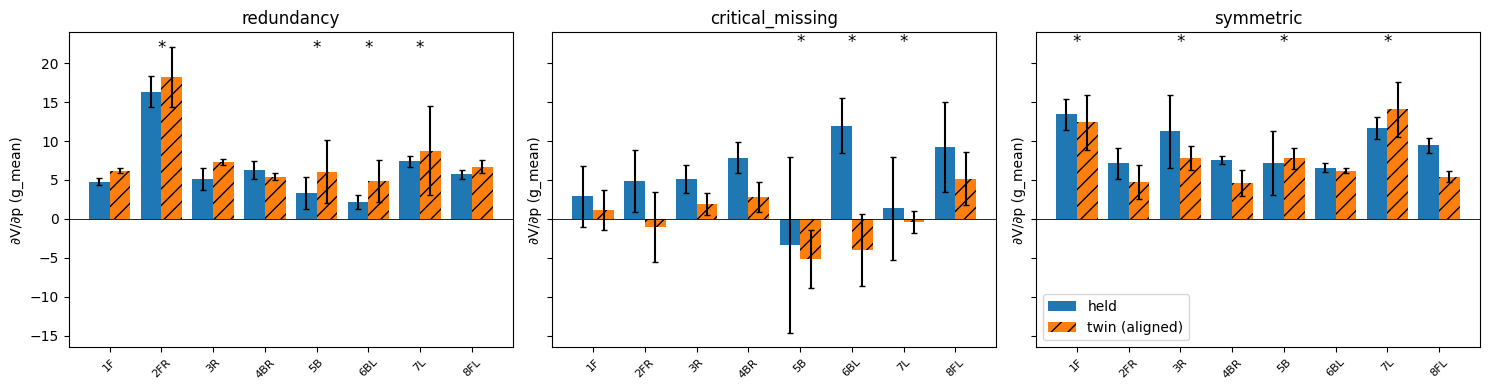

In [15]:
from matplotlib.patches import Patch
s2 = np.load(ROOT / 'data' / 'value_grad_prop' / 'step2_p0.75-0.25.npz', allow_pickle=True)
names = list(s2['names']); hm = s2['held_mask']; tmap = s2['tmap']
gh = s2['g_held']; gt = s2['g_twin']                       # (seed, set, 8)
LEG = ['1F', '2FR', '3R', '4BR', '5B', '6BL', '7L', '8FL']
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4), sharey=True)
for gi, (ax, nm) in enumerate(zip(np.atleast_1d(axes), names)):
    hmn, hsd = gh[:, gi].mean(0), gh[:, gi].std(0)
    # align twin onto held frame: held leg L partners twin leg tmap[gi,L]
    al = np.array([gt[:, gi, tmap[gi, l] - 1] for l in range(8)]).T   # (seed, 8) in held frame
    amn, asd = al.mean(0), al.std(0)
    x = np.arange(8)
    ax.bar(x - 0.2, hmn, 0.4, yerr=hsd, capsize=2, color='C0', label='held')
    ax.bar(x + 0.2, amn, 0.4, yerr=asd, capsize=2, color='C1', hatch='//', label='twin (aligned)')
    for l in range(8):                                      # mark which legs are on in the held body
        if hm[gi, l]: ax.text(l, ax.get_ylim()[1] * 0.92, '*', ha='center', fontsize=12)
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(LEG, rotation=45, fontsize=8)
    ax.set_title(nm); ax.set_ylabel('∂V/∂p (g_mean)')
np.atleast_1d(axes)[-1].legend()
plt.tight_layout(); plt.show()

## Step 3 — held-out 5-leg interpolation

**Hypothesis.** Every 5-leg body is held out of training, so `V` never rolled out one and the 5-ish
`p`-region is sparsely seen. Does the gradient still make sense there, or is it garbage off the training
set? We expect the held-out 5-leg `∂V/∂p`-vs-`p` curve to **coincide** with the in-distribution Step-1
curve.

**How it works.** Bypass the guard, use 5-leg topologies as bias centers, sweep `p` the √U way, and
overlay the held-out curve (per seed) on the **in-distribution Step-1 pooled curve**.

**What we found.** The curves **coincide** in sign and shape (the held-out runs even sit a touch *higher*
at low `p`). The codesign signal interpolates cleanly onto a leg count `V` never trained on — generalizes
off the training set.

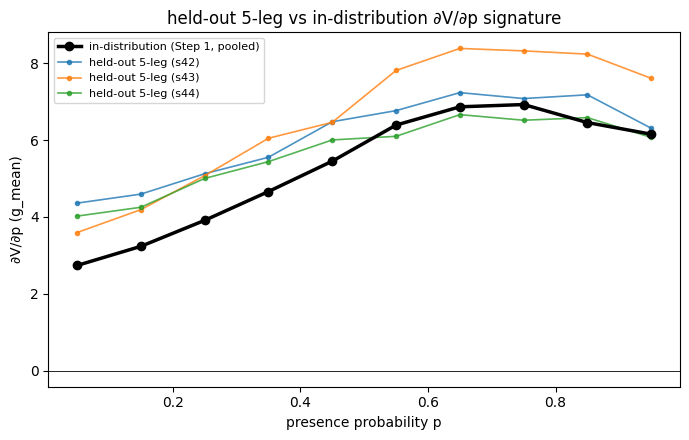

In [16]:
s3runs = sorted((ROOT / 'data' / 'value_grad_prop').glob('*/step3.npz'))
S3 = {p.parent.name: np.load(p, allow_pickle=True) for p in s3runs}
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CEN, binned(pp, gg), color='k', lw=2.5, marker='o', label='in-distribution (Step 1, pooled)', zorder=3)
for s, d in S3.items():
    ax.plot(CEN, binned(d['p'].ravel(), d['g_mean'].ravel()), marker='.', lw=1.2, alpha=0.8,
            label=f'held-out 5-leg ({s})')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean)')
ax.set_title('held-out 5-leg vs in-distribution ∂V/∂p signature'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 3 — per-limb marginal value: 5-leg base vs ±1 leg

**Hypothesis.** Take a held-out 5-leg base, then **add** a random leg (→6) or **remove** a present one
(→4). We expected each existing limb's `∂V/∂p` to **fall** when you add a leg (diminishing returns) and
**rise** when you remove one (each remaining leg now more critical).

**How it works.** Three random held-out 5-leg bases (one per column). **Top row:** base vs the +1 (6-leg)
version; **bottom row:** base vs the −1 (4-leg) version. Bars are seed-avg ± seed-std at interior obs-p
(0.75 on / 0.25 off); the added/removed slot is shaded and `*` marks each present (on) limb.

**What we found.** The **add** side is clean — adding a leg lowers every remaining limb's gradient in all
three bases (diminishing returns ✓). The **remove** side is mixed and noisy — sometimes up, sometimes
down — no clean symmetric "each leg more critical" story.

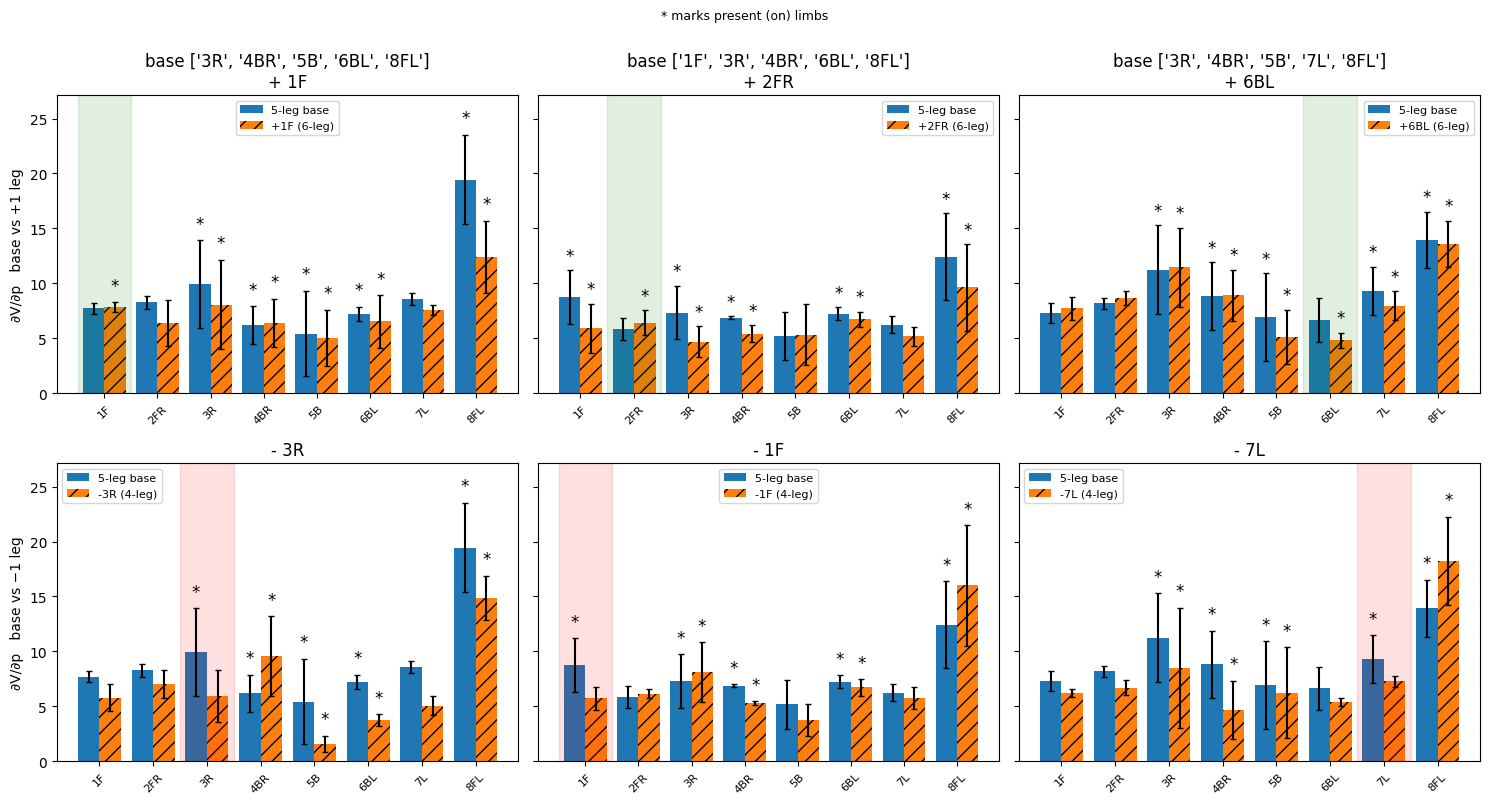

In [17]:
a3 = np.load(ROOT / 'data' / 'value_grad_prop' / 'step3_addrm.npz', allow_pickle=True)
LEG = ['1F', '2FR', '3R', '4BR', '5B', '6BL', '7L', '8FL']
gb, ga, gr = a3['g_base'], a3['g_add'], a3['g_rm']          # (seed, base, 8)
bm, am, rmsk = a3['base_mask'], a3['add_mask'], a3['rm_mask']
aleg, rleg = a3['added_leg'], a3['removed_leg']
NB_ = gb.shape[1]; x = np.arange(8); w = 0.4

def panel(ax, base, mod, mod_lbl, hl, hl_color, base_on, mod_on):
    bm_, bs = base.mean(0), base.std(0)
    mm_, ms = mod.mean(0), mod.std(0)
    ax.bar(x - w/2, bm_, w, yerr=bs, capsize=2, color='C0', label='5-leg base')
    ax.bar(x + w/2, mm_, w, yerr=ms, capsize=2, color='C1', hatch='//', label=mod_lbl)
    ax.axvspan(hl - 0.5, hl + 0.5, color=hl_color, alpha=0.12)   # the added/removed slot
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(LEG, rotation=45, fontsize=8)
    pad = 0.03 * max(1.0, float((bm_ + bs).max()), float((mm_ + ms).max()))
    for l in range(8):                                          # star above each ON bar
        if base_on[l]: ax.text(l - w/2, max(bm_[l] + bs[l], 0) + pad, '*', ha='center', va='bottom', fontsize=12)
        if mod_on[l]:  ax.text(l + w/2, max(mm_[l] + ms[l], 0) + pad, '*', ha='center', va='bottom', fontsize=12)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, NB_, figsize=(5 * NB_, 8), sharey='row')
for i in range(NB_):
    base_legs = [LEG[l] for l in range(8) if bm[i, l]]
    panel(axes[0, i], gb[:, i], ga[:, i], f'+{LEG[aleg[i]-1]} (6-leg)', aleg[i] - 1, 'green', bm[i], am[i])
    axes[0, i].set_title(f'base {base_legs}\n+ {LEG[aleg[i]-1]}')
    panel(axes[1, i], gb[:, i], gr[:, i], f'-{LEG[rleg[i]-1]} (4-leg)', rleg[i] - 1, 'red', bm[i], rmsk[i])
    axes[1, i].set_title(f'- {LEG[rleg[i]-1]}')
for r in range(2):                                             # headroom so stars don't clip (sharey=row)
    lo, hi = axes[r, 0].get_ylim(); axes[r, 0].set_ylim(lo, hi + 0.10 * (hi - lo))
axes[0, 0].set_ylabel('∂V/∂p   base vs +1 leg'); axes[1, 0].set_ylabel('∂V/∂p   base vs −1 leg')
fig.suptitle('* marks present (on) limbs', y=1.0, fontsize=9)
plt.tight_layout(); plt.show()

## Grounding — does realized return back up V and its gradient?

**Hypothesis.** Steps 1–3 judged `∂V/∂p` against *intuition*; here we ground it against *realized return*.
If the codesign signal is trustworthy, two things should hold: (1) the critic's value `V` tracks realized
return `R` across bodies, and (2) `∂V/∂p_L` predicts the **realized** marginal value of leg `L`,
`ΔR_L = R(body with L) − R(body without L)`. We were especially worried (the critical-missing case) that
the gradient might fail to flag genuinely useful legs in broken bodies — now we can check on real returns.

**How it works.** 16 in-distribution base bodies (4 each at 3/4/6/7 legs), each built deterministically at
interior obs-p (0.75/0.25) alongside its 8 single-leg **toggles** (flip each leg on↔off). For every body
we measure realized return `R` (deterministic-μ rollout) and value `V` (at reset); at each base we also
take per-leg `∂V/∂p`. Seed-averaged over s42/43/44. *Left:* `V` vs `R`. *Right:* `∂V/∂p_L` vs realized
`ΔR_L`, colored by **base leg-count** (the punchline).

**What we found.** Revealing, and a bit sobering.
- **Value tracks return well in rank** — Pearson +0.93, Spearman +0.93; the critic orders bodies
  good→bad correctly. (Absolute `V` is *compressed* — ~24–89 vs realized 24–5187 — because it predicts
  *discounted* return-to-go; calibration is in rank, not scale.)
- **The gradient nails the sign (99.2%)** — it almost always correctly says "this leg is worth
  adding/keeping," and indeed nearly every leg has positive realized value (more legs better, again).
- **But the gradient's *magnitude* barely predicts realized leg value** — Pearson only +0.17 overall, and
  the correlation **lives only in already-functional bodies**: 6–7-leg bases r≈+0.35, but **3–4-leg bases
  r≈0** (no relationship). Adding is somewhat predictable (r≈+0.30), removing is not (ρ≈+0.03). The
  gradient is squashed into a narrow band (+2.7…+15) while realized leg values span −330…+2800, so it
  can't express the ~10× spread.

**Takeaway.** This confirms the critical-missing worry on real returns: from a sparse/broken body the
gradient gives a reliable "add legs" *direction* but can't tell you *which* leg matters — exactly where a
generator would need the guidance. The magnitude only becomes informative once the body already walks
(likely linked to the compressed value head: a `V` that doesn't span the return range has a gradient that
can't either).

In [ ]:
from scipy.stats import spearmanr
abl = np.load(ROOT / 'data' / 'value_grad_prop' / 'ablation.npz', allow_pickle=True)
V, R, gB = abl['V'], abl['R'], abl['g_base']          # (seed,base,9) V & R ; (seed,base,8) base ∂V/∂p
bm, lc = abl['base_mask'], abl['leg_count']
Vm, Rm, Gm = V.mean(0), R.mean(0), gB.mean(0)         # seed-avg

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# Left: value calibration — does the critic's V track realized return R, over all bodies?
lcb = np.repeat(lc[:, None], V.shape[2], 1).ravel()   # base leg-count tag per body
rr, vv = Rm.ravel(), Vm.ravel()
sc = axL.scatter(rr, vv, c=lcb, cmap='viridis', s=22)
plt.colorbar(sc, ax=axL, label='base leg-count')
axL.set_xlabel('realized return R'); axL.set_ylabel('critic value V at reset (discounted units)')
axL.set_title(f'value calibration   r={np.corrcoef(rr, vv)[0,1]:+.2f}  '
              f'ρ={spearmanr(rr, vv).statistic:+.2f}   (V compressed vs R)')

# Right: gradient grounding — does ∂V/∂p_L predict the realized marginal value of leg L?
sign = np.where(bm == 1, 1.0, -1.0)                   # +1 if leg on in base else -1
dR = sign * (Rm[:, [0]] - Rm[:, 1:])                  # (base,8): R(with L) − R(without L)
x, y = Gm.ravel(), dR.ravel()
lcg = np.repeat(lc[:, None], 8, 1).ravel()            # base leg-count per (base,leg) point
sc2 = axR.scatter(x, y, c=lcg, cmap='viridis', s=22)
plt.colorbar(sc2, ax=axR, label='base leg-count')
axR.axhline(0, color='k', lw=0.6); axR.axvline(0, color='k', lw=0.6)
axR.set_xlabel('∂V/∂p at base (codesign signal)'); axR.set_ylabel('realized ΔR = R(with L) − R(without L)')
axR.set_title(f'gradient grounding   r={np.corrcoef(x, y)[0,1]:+.2f}  ρ={spearmanr(x, y).statistic:+.2f}  '
              f'sign-agree={(np.sign(x) == np.sign(y)).mean():.2f}')
plt.tight_layout(); plt.show()

print(f'value calibration:  pearson {np.corrcoef(rr, vv)[0,1]:+.3f}  spearman {spearmanr(rr, vv).statistic:+.3f}')
print(f'gradient grounding: pearson {np.corrcoef(x, y)[0,1]:+.3f}  spearman {spearmanr(x, y).statistic:+.3f}  '
      f'sign-agree {(np.sign(x) == np.sign(y)).mean():.3f}')
on = (bm == 1).ravel()
print(f'  add (leg off): r={np.corrcoef(x[~on], y[~on])[0,1]:+.3f}   remove (leg on): ρ={spearmanr(x[on], y[on]).statistic:+.3f}')
for c in sorted(set(lc.tolist())):
    m = lcg == c
    print(f'  {c}-leg bases: pearson {np.corrcoef(x[m], y[m])[0,1]:+.3f}  (n={m.sum()})')

## Why is the magnitude wrong for poor morphs? — a value-learning failure, not a calculus artifact

**Hypothesis.** Grounding showed `∂V/∂p`'s magnitude predicts realized leg value only in functional
bodies (6–7 legs), not sparse ones (3–4). Two candidate causes: **(A)** the gradient is a *local slope*
that can't see the discrete "tips it over the locomotion threshold" jump that adding a leg to a broken
body causes; or **(B)** the *value function itself* never learned which leg matters in the un-walkable
region, so there's no correct magnitude to extract. We test which.

**How it works.** Reuse the ablation data. *Left:* correlate realized `ΔR` with **two** predictors per
leg-count — the gradient `∂V/∂p` AND the critic's own **finite-difference** `ΔV = V(with leg) − V(without
leg)`, which actually crosses the toggle. If (A), `ΔV` should beat the gradient; if (B), both fail
together. *Right:* decompose the sparse-body gradient into **cross-leg signal** (spread across legs within
a body) vs **seed-to-seed noise** — is the wrong magnitude just noise, or a confident, reproducible
signal?

**What we found — it's (B), decisively.**
- **Not a calculus artifact:** the critic's finite-difference `ΔV` fails *just as badly* as the gradient
  in sparse bodies (3-leg: grad −0.01, ΔV +0.06; 4-leg both ≈ −0.05) and both recover together at 6–7
  legs. So `V` itself doesn't encode which leg matters — the gradient faithfully reports a `V` that's
  wrong there.
- **Not noise:** the sparse-body per-leg signal is *large and reproducible* (SNR ≈ 1.9, **higher** than
  full bodies) — `V` confidently assigns a per-leg ranking that simply doesn't match reality.
- **`V` starves the floor:** it compresses all 3-leg bodies into `V∈[35,39]` (realized returns in the
  hundreds), allocating almost no output range to the un-walkable region.

**Why.** Below quorum a body can't walk *regardless of which legs it has*, so during training the return
signal carries ~no information about per-leg importance there — every bad body returns ~floor. `V` can't
learn structure it never saw; it interpolates from functional bodies (right sign, arbitrary magnitudes).
Compounded by credit assignment (a broken body never *uses* a leg on-policy) and complementarity (the true
per-leg value depends on *absent* legs — not a function of the current body at all). You can't
differentiate your way to information the value function never contained. The fix is data/representation
in the floor region (curriculum, informative shaping), not value normalization — or treat the gradient as
**sign-only**.

In [ ]:
from scipy.stats import spearmanr
abl = np.load(ROOT / 'data' / 'value_grad_prop' / 'ablation.npz', allow_pickle=True)
V, R, gB = abl['V'], abl['R'], abl['g_base']
bm, lc = abl['base_mask'], abl['leg_count']
Vm, Rm, Gm = V.mean(0), R.mean(0), gB.mean(0)
sign = np.where(bm == 1, 1.0, -1.0)
dR = sign * (Rm[:, [0]] - Rm[:, 1:])            # realized marginal value of leg L     (base,8)
dV = sign * (Vm[:, [0]] - Vm[:, 1:])            # critic finite-diff predicted leg value (base,8)
counts = sorted(set(lc.tolist())); xpos = np.arange(len(counts)); w = 0.38

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: corr(predictor, realized ΔR) by leg-count — gradient vs the critic's OWN finite-difference.
def corr_by(arr):
    return [np.corrcoef(arr[lc == c].ravel(), dR[lc == c].ravel())[0, 1] for c in counts]
axL.bar(xpos - w/2, corr_by(Gm), w, color='C0', label='gradient ∂V/∂p')
axL.bar(xpos + w/2, corr_by(dV), w, color='C1', hatch='//', label='critic finite-diff ΔV')
axL.axhline(0, color='k', lw=0.6); axL.set_xticks(xpos); axL.set_xticklabels([f'{c} legs' for c in counts])
axL.set_ylabel('Pearson(predictor, realized ΔR)')
axL.set_title('not a calculus artifact:\ngradient and finite-diff fail together in sparse bodies')
axL.legend(fontsize=8)

# Right: is the sparse-body magnitude just noise? cross-leg signal vs seed-to-seed noise.
spread = [Gm[lc == c].std(1).mean() for c in counts]   # spread across legs within a body = the signal
noise  = [gB.std(0)[lc == c].mean() for c in counts]   # seed-to-seed std of a single leg's gradient
axR.bar(xpos - w/2, spread, w, color='C2', label='cross-leg signal (spread)')
axR.bar(xpos + w/2, noise,  w, color='C3', hatch='//', label='seed-to-seed noise')
axR.set_xticks(xpos); axR.set_xticklabels([f'{c} legs' for c in counts])
axR.set_ylabel('∂V/∂p magnitude units')
axR.set_title('not noise: sparse-body signal is large + reproducible\n(SNR>1) yet uncorrelated with reality')
axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('corr(∂V/∂p, ΔR) vs corr(ΔV, ΔR) by leg-count:')
for c, g_, v_ in zip(counts, corr_by(Gm), corr_by(dV)):
    print(f'  {c}-leg: gradient {g_:+.2f}   finite-diff {v_:+.2f}')
print('V allocates almost no output range to low-return bodies:')
for c in counts:
    m = lc == c
    print(f'  {c}-leg: V_base in [{Vm[m,0].min():.0f},{Vm[m,0].max():.0f}]   (realized R_base mean {Rm[m,0].mean():.0f})')

## Phase 2 — gradient through a continuous-`p` generator (conditioning check)

**Hypothesis.** Does the *sign* survive being routed through a generator network? The earlier **binary**
version failed here: its discrete generator's sigmoid saturated and the gradient collapsed ~3 orders of
magnitude. The continuous-`p` recast should keep the sigmoid **unsaturated** (targets are interior
probabilities) and preserve the sign that ascent consumes.

**How it works.** A small transformer (the generator analogue) is pretrained (MSE) to regress each leg's
`p` from a *scattered-`p`* puzzle — it must attend across tokens to gather each value — then frozen and
composed in front of the frozen value net (its 8 `p̂` outputs feed V's 8 tied length slots directly). We
compare the **composed** input-gradient to the **direct** `∂V/∂p` at the same states. *Left:* per-(leg,
env) scatter, direct (x) vs composed (y); *right:* backward grad-L2-norm chain from generator **output**
back through layers to **input** — should not collapse.

**What we found.** The sign **survives** — sign-alignment **0.94**, and the norm chain doesn't vanish
(ends above where it starts). Magnitude is only *moderately* preserved (corr ~0.55), but sign is what
ascent needs. The continuous recast fixes v1's collapse by construction.

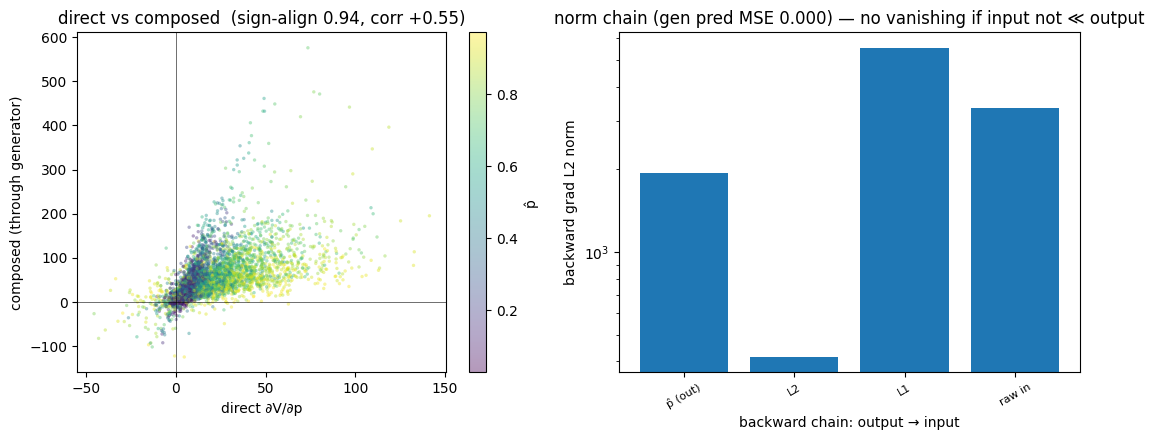

In [18]:
p2 = np.load(ROOT / 'data' / 'value_grad_prop' / 'phase2.npz', allow_pickle=True)
d = p2['direct'].ravel(); cm = p2['composed'].ravel(); ph = p2['phat'].ravel()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax[0].scatter(d, cm, s=6, alpha=0.4, c=ph, cmap='viridis', edgecolors='none')
ax[0].axhline(0, color='k', lw=0.4); ax[0].axvline(0, color='k', lw=0.4)
ax[0].set_xlabel('direct ∂V/∂p'); ax[0].set_ylabel('composed (through generator)')
ax[0].set_title(f'direct vs composed  (sign-align {float(p2["sign_match"]):.2f}, '
                f'corr {float(p2["corr"]):+.2f})')
fig.colorbar(sc, ax=ax[0], label='p̂')
ch = p2['chain_norms']
labels = ['p̂ (out)'] + [f'L{len(ch)-2-i}' for i in range(len(ch) - 2)] + ['raw in']
ax[1].bar(range(len(ch)), ch); ax[1].set_yscale('log')
ax[1].set_xticks(range(len(ch))); ax[1].set_xticklabels(labels, rotation=30, fontsize=8)
ax[1].set_xlabel('backward chain: output → input'); ax[1].set_ylabel('backward grad L2 norm')
ax[1].set_title(f'norm chain (gen pred MSE {float(p2["pred_mse"]):.3f}) — no vanishing if input not ≪ output')
plt.tight_layout(); plt.show()